# Audio Captioning -- Results Comparison

**Baseline config:** 2-layer MLP projection, prefix_len=8, dropout=0.3, weight_decay=0.1, batch_size=8, greedy decoding.  
**LRs:** tuned per model via Optuna (16 trials, 8 proxy epochs).  
**Evaluation:** stage 2 (projection + LM fine-tuned), CLAP precomputed embeddings.

Sections:
1. Baseline comparison across models
2. Architecture ablation tables per model
3. Training curves (val loss per epoch)
4. Sample predictions (best, worst, failure cases)

In [16]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIR = Path("../results")
MODELS = ["gpt2", "t5", "opt", "phi2", "llama"]
METRICS = ["BLEU-1", "BLEU-4", "METEOR", "ROUGE-L", "CIDEr", "FENSE"]

In [17]:
def load_json(path):
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None


def collect_eval_results():
    """Collect all ablation eval JSONs into a flat list of dicts."""
    rows = []
    for model in MODELS:
        model_dir = RESULTS_DIR / model
        if not model_dir.exists():
            continue
        for f in sorted(model_dir.glob(f"{model}_ablation_*.json")):
            d = load_json(f)
            if d is None:
                continue
            tag = f.stem.replace(f"{model}_ablation_", "")
            row = {"model": model, "tag": tag, **d["metrics"]}
            rows.append(row)
    return pd.DataFrame(rows)


def collect_training_results():
    """Collect all stage1/stage2 training JSONs."""
    rows = []
    for model in MODELS:
        model_dir = RESULTS_DIR / model
        if not model_dir.exists():
            continue
        for f in sorted(model_dir.glob(f"*_stage*.json")):
            d = load_json(f)
            if d is None:
                continue
            tag = f.stem.replace(f"_stage{d['stage']}", "")
            rows.append({
                "model": model,
                "tag": tag,
                "stage": d["stage"],
                "best_val_loss": d["best_val_loss"],
                "stopped_epoch": d["stopped_epoch"],
                "history": d["history"],
                "hyperparams": d["hyperparams"],
            })
    return rows


eval_df = collect_eval_results()
training_results = collect_training_results()
print(f"Loaded {len(eval_df)} eval results, {len(training_results)} training results")

Loaded 17 eval results, 34 training results


## 1. Baseline Comparison Across Models

In [18]:
baselines = eval_df[eval_df["tag"] == eval_df["model"]].copy()
if len(baselines) > 0:
    baselines = baselines.set_index("model")[METRICS].round(4)
    baselines = baselines.reindex([m for m in MODELS if m in baselines.index])
    display(baselines.style.background_gradient(cmap="Greys", vmin=-0.5, axis=None, subset=METRICS))
else:
    print("No baseline results found.")

,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr,FENSE
model,,,,,,
gpt2,0.283800,0.061000,0.203800,0.238400,0.345200,0.376000
t5,0.298000,0.057800,0.198400,0.233900,0.328700,0.334000
opt,0.275800,0.059500,0.212100,0.231800,0.344200,0.366200


## 2. Architecture Ablation Tables

In [19]:
BASELINE_DESC = "Baseline: depth=2, prefix_len=8, dropout=0.3"

for model in MODELS:
    model_df = eval_df[eval_df["model"] == model].copy()
    if len(model_df) == 0:
        continue
    print(f"\n{'='*60}")
    print(f"  {model.upper()} -- Architecture Ablations")
    print(f"  {BASELINE_DESC}")
    print(f"{'='*60}")
    table = model_df.set_index("tag")[METRICS].round(4)
    styled = table.style
    for col in METRICS:
        styled = styled.background_gradient(cmap="Greys", subset=[col], vmin=table[col].min() - 0.02)
    display(styled)


  GPT2 -- Architecture Ablations
  Baseline: depth=2, prefix_len=8, dropout=0.3


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr,FENSE
tag,,,,,,
gpt2,0.283800,0.061000,0.203800,0.238400,0.345200,0.376000
gpt2_depth1,0.279500,0.052000,0.200400,0.230000,0.290400,0.353000
gpt2_depth3,0.297000,0.065200,0.219100,0.244200,0.374600,0.402000
gpt2_drop0.1,0.293900,0.064900,0.209100,0.242200,0.345400,0.382500
gpt2_drop0.5,0.269700,0.048700,0.189300,0.222600,0.271300,0.395200
gpt2_prefix16,0.293600,0.063900,0.207800,0.237600,0.355100,0.362100
gpt2_prefix4,0.277100,0.059800,0.208900,0.238200,0.378600,0.393900



  T5 -- Architecture Ablations
  Baseline: depth=2, prefix_len=8, dropout=0.3


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr,FENSE
tag,,,,,,
t5,0.298000,0.057800,0.198400,0.233900,0.328700,0.334000
t5_depth1,0.126000,0.033700,0.091500,0.117400,0.115100,0.031700
t5_depth3,0.073600,0.013600,0.054100,0.093900,0.040000,0.028400
t5_drop0.1,0.267000,0.052900,0.182800,0.235200,0.276900,0.372400
t5_drop0.5,0.290400,0.056700,0.194100,0.238400,0.321600,0.385000
t5_prefix16,0.277000,0.050500,0.185300,0.235000,0.284700,0.381400
t5_prefix4,0.284400,0.054500,0.191300,0.236000,0.321800,0.400900



  OPT -- Architecture Ablations
  Baseline: depth=2, prefix_len=8, dropout=0.3


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr,FENSE
tag,,,,,,
opt,0.275800,0.059500,0.212100,0.231800,0.344200,0.366200
opt_prefix16,0.289300,0.062100,0.214200,0.237300,0.351400,0.403500
opt_prefix4,0.291200,0.057900,0.206600,0.238200,0.318800,0.417200


## 3. Training Curves

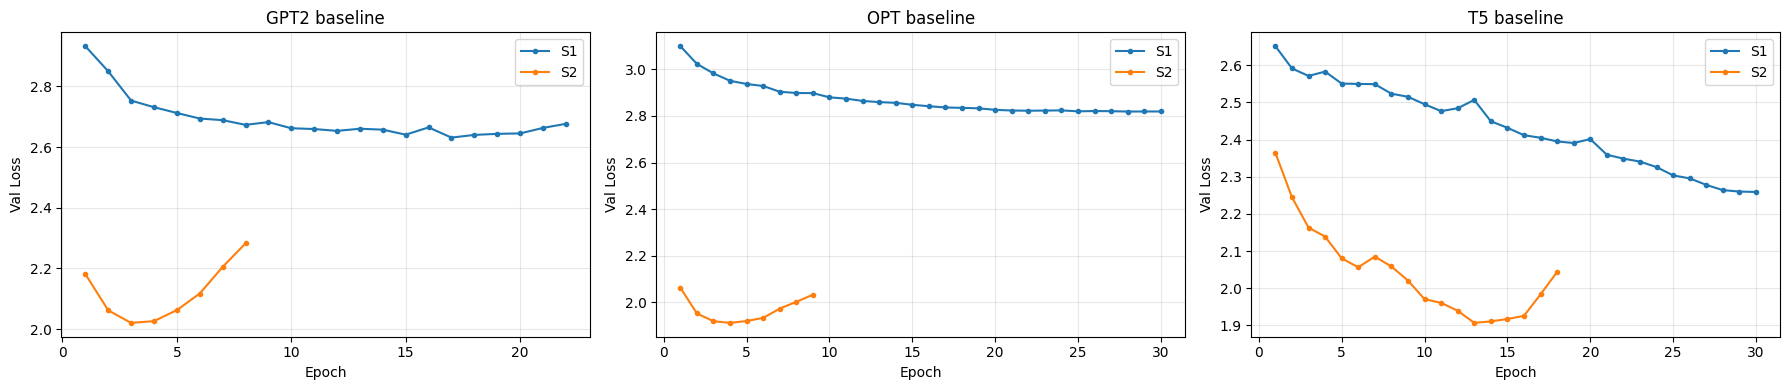

In [20]:
# Baseline training curves (S1 + S2) for each model
baseline_training = [r for r in training_results if r["tag"] == r["model"]]
models_with_data = sorted(set(r["model"] for r in baseline_training))

if models_with_data:
    fig, axes = plt.subplots(1, len(models_with_data), figsize=(6 * len(models_with_data), 4), squeeze=False)
    for idx, model in enumerate(models_with_data):
        ax = axes[0][idx]
        for r in baseline_training:
            if r["model"] != model:
                continue
            epochs = [h["epoch"] for h in r["history"]]
            val_loss = [h["val_loss"] for h in r["history"]]
            ax.plot(epochs, val_loss, marker="o", markersize=3, label=f"S{r['stage']}")
        ax.set_title(f"{model.upper()} baseline")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Val Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No baseline training results found.")

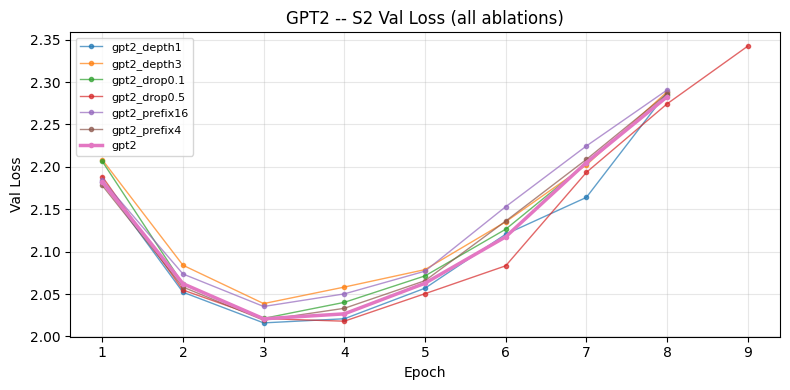

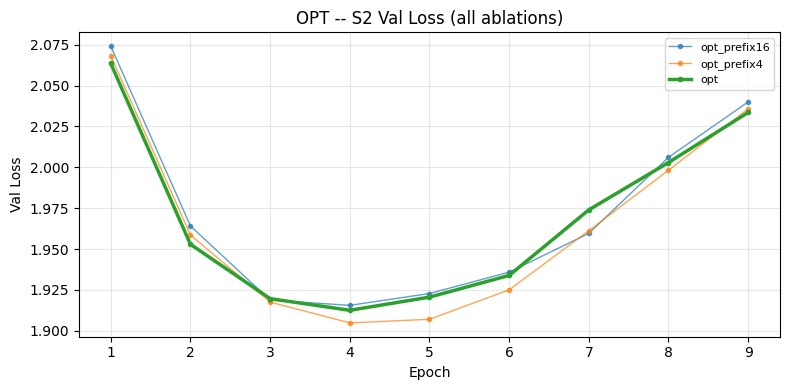

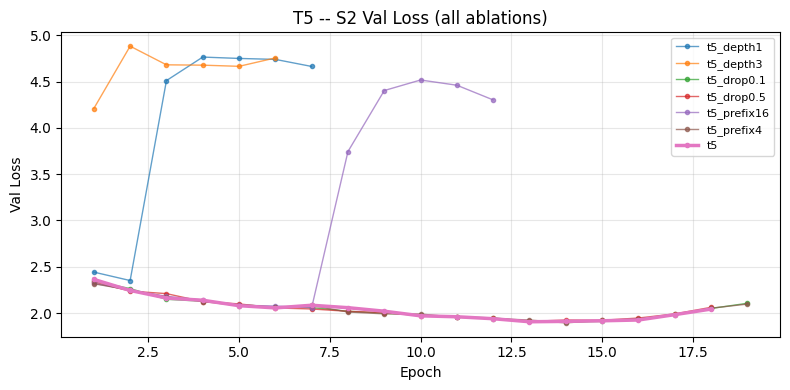

In [21]:
# S2 training curves for all ablation variants per model
s2_results = [r for r in training_results if r["stage"] == 2]
models_with_s2 = sorted(set(r["model"] for r in s2_results))

for model in models_with_s2:
    model_runs = [r for r in s2_results if r["model"] == model]
    fig, ax = plt.subplots(figsize=(8, 4))
    for r in model_runs:
        epochs = [h["epoch"] for h in r["history"]]
        val_loss = [h["val_loss"] for h in r["history"]]
        label = r["tag"]
        is_baseline = r["tag"] == r["model"]
        ax.plot(epochs, val_loss, marker="o", markersize=3, label=label,
                linewidth=2.5 if is_baseline else 1, alpha=1.0 if is_baseline else 0.7)
    ax.set_title(f"{model.upper()} -- S2 Val Loss (all ablations)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Loss")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. Sample Predictions

In [22]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction


def score_predictions(predictions):
    """Score each prediction with sentence-level BLEU-4."""
    smooth = SmoothingFunction().method1
    scored = []
    for p in predictions:
        ref = p["reference"].lower().split()
        hyp = p["hypothesis"].lower().split()
        bleu = sentence_bleu([ref], hyp, weights=(0.25, 0.25, 0.25, 0.25),
                             smoothing_function=smooth)
        scored.append({**p, "bleu4": bleu})
    return sorted(scored, key=lambda x: x["bleu4"], reverse=True)


def show_predictions(scored, title, indices):
    """Display selected predictions."""
    print(f"\n--- {title} ---")
    for i in indices:
        if i >= len(scored):
            continue
        p = scored[i]
        print(f"  BLEU-4: {p['bleu4']:.4f}")
        print(f"  REF: {p['reference']}")
        print(f"  HYP: {p['hypothesis']}")
        print()

In [23]:
# Best, median, worst predictions for each baseline model
for model in MODELS:
    path = RESULTS_DIR / model / f"{model}_ablation_{model}.json"
    d = load_json(path)
    if d is None:
        continue
    scored = score_predictions(d["predictions"])
    n = len(scored)
    mid = n // 2

    print(f"\n{'='*60}")
    print(f"  {model.upper()} -- Sample Predictions ({n} total)")
    print(f"{'='*60}")

    show_predictions(scored, "BEST (top 3)", [0, 1, 2])
    show_predictions(scored, "MEDIAN", [mid - 1, mid, mid + 1])
    show_predictions(scored, "WORST (bottom 3)", [n - 3, n - 2, n - 1])


  GPT2 -- Sample Predictions (529 total)

--- BEST (top 3) ---
  BLEU-4: 0.4430
  REF: This is a country/western swing music piece. There is a male vocalist singing melodically in the lead with a story-telling attitude. The main tune is being played by the electric guitar with a bass guitar backing. The rhythm is being played by the acoustic drums. The atmosphere is easygoing. This piece could be playing in the background at an American roadside diner.
  HYP: This is a pop rock music piece. There is a male vocalist singing melodically. The main tune is being played by the acoustic guitar while the bass guitar is playing in the background. The rhythm is provided by a simple acoustic drum beat. The atmosphere is lively. This piece could be playing in the background at

  BLEU-4: 0.3768
  REF: This is an indie rock music piece. There is a male vocalist singing melodically in the lead. There is an electric guitar playing a simple tune with a strong reverb effect. The bass guitar is playin

## 5. Failure Cases

Predictions where the model produced degenerate output: repetition, empty, or very short.

In [24]:
import re


def detect_failures(predictions):
    failures = []
    for p in predictions:
        hyp = p["hypothesis"].strip()
        reason = None

        if len(hyp) == 0:
            reason = "empty"
        elif len(hyp.split()) < 3:
            reason = "too short"
        else:
            words = hyp.lower().split()
            if len(set(words)) <= max(2, len(words) * 0.15):
                reason = "repetitive"
            elif re.search(r"(\b\w+\b)(?:\s+\1){4,}", hyp.lower()):
                reason = "word repetition"

        if reason:
            failures.append({**p, "failure": reason})
    return failures


for model in MODELS:
    model_dir = RESULTS_DIR / model
    if not model_dir.exists():
        continue
    for f in sorted(model_dir.glob(f"{model}_ablation_*.json")):
        d = load_json(f)
        if d is None:
            continue
        tag = f.stem.replace(f"{model}_ablation_", "")
        failures = detect_failures(d["predictions"])
        if failures:
            print(f"{model}/{tag}: {len(failures)} failures out of {len(d['predictions'])}")
            for fail in failures[:3]:
                print(f"  [{fail['failure']}]")
                print(f"  REF: {fail['reference'][:100]}")
                print(f"  HYP: {fail['hypothesis'][:100]}")
                print()
            if len(failures) > 3:
                print(f"  ... and {len(failures) - 3} more\n")

gpt2/gpt2_prefix16: 1 failures out of 529
  [word repetition]
  REF: Empowering youthful music with heavily processed female vocals and compressed drum samples. big clap
  HYP: The Electro song features a passionate female vocal, alongside harmonizing background female vocals,

t5/t5_depth3: 529 failures out of 529
  [word repetition]
  REF: The song is an instrumental music piece. The song is slow tempo with an electric guitar playing lead
  HYP: The low quality recording features a a a a a a a a a a a a a a a a a a a a a a a a a a a a a

  [word repetition]
  REF: The song is an instrumental. The tempo is medium with a guitar accompaniment and leads into a strong
  HYP: This is a male vocaliststic guitarstic guitarstic guitarstic guitarstic guitarstic guitarstic guitar

  [word repetition]
  REF: This is a military anthem sung by male voices in the French language. The choir sings in a grave but
  HYP: This is a male vocaliststic guitarstic guitarstic guitarstic guitarstic guitarstic

## 6. Summary Table (all ablations, all models)

In [25]:
if len(eval_df) > 0:
    summary = eval_df.copy()
    summary["variant"] = summary["model"] + "/" + summary["tag"]
    summary = summary.set_index("variant")[METRICS].round(4)
    summary = summary.sort_values("FENSE", ascending=False)
    styled = summary.style
    for col in METRICS:
        styled = styled.background_gradient(cmap="Greys", subset=[col], vmin=summary[col].min() - 0.02)
    display(styled)

,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr,FENSE
variant,,,,,,
opt/opt_prefix4,0.291200,0.057900,0.206600,0.238200,0.318800,0.417200
opt/opt_prefix16,0.289300,0.062100,0.214200,0.237300,0.351400,0.403500
gpt2/gpt2_depth3,0.297000,0.065200,0.219100,0.244200,0.374600,0.402000
t5/t5_prefix4,0.284400,0.054500,0.191300,0.236000,0.321800,0.400900
gpt2/gpt2_drop0.5,0.269700,0.048700,0.189300,0.222600,0.271300,0.395200
gpt2/gpt2_prefix4,0.277100,0.059800,0.208900,0.238200,0.378600,0.393900
t5/t5_drop0.5,0.290400,0.056700,0.194100,0.238400,0.321600,0.385000
gpt2/gpt2_drop0.1,0.293900,0.064900,0.209100,0.242200,0.345400,0.382500
t5/t5_prefix16,0.277000,0.050500,0.185300,0.235000,0.284700,0.381400
